# 02 - Feature engineering validation

Spot-check the Elo rating trajectory and rolling-form features built by `src.features.elo` and `src.features.build_features` against a few well-known fighters' real career arcs, and inspect the final model feature table.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from src.features.elo import compute_elo

fights = pd.read_csv('../data/processed/fights.csv', parse_dates=['event_date'],
                     dtype={'fighter_1_id': 'string', 'fighter_2_id': 'string', 'winner_id': 'string'})
fighters = pd.read_csv('../data/processed/fighters.csv')
per_fight, current_ratings = compute_elo(fights)

## Elo trajectory for a few well-known fighters

If the Elo system is working, dominant champions (Jon Jones, Islam Makhachev, Georges St-Pierre) should show a long-run upward trend through their careers with dips after any losses.

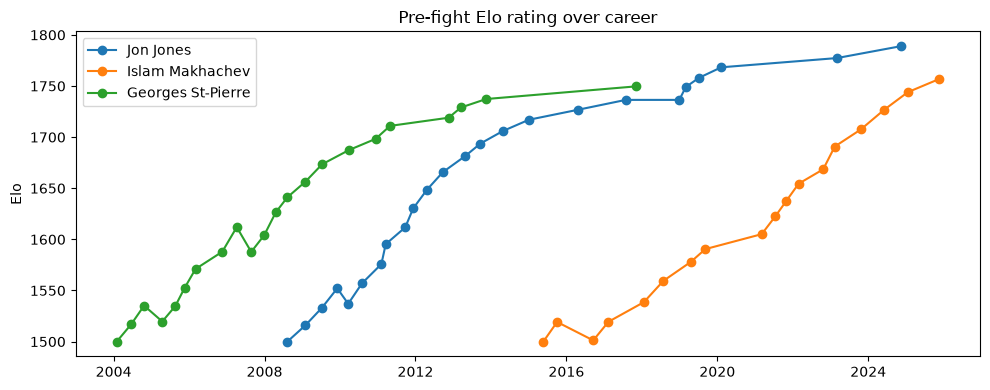

In [2]:
name_to_id = fighters.set_index('name')['fighter_id']
fights_sorted = fights.sort_values('event_date', kind='stable').reset_index(drop=True)
per_fight_dated = per_fight.merge(fights_sorted[['fight_id', 'event_date', 'fighter_1_id', 'fighter_2_id']], on='fight_id')

def elo_history(fighter_name):
    fid = name_to_id.get(fighter_name)
    as_1 = per_fight_dated[per_fight_dated['fighter_1_id'] == fid][['event_date', 'fighter_1_elo_pre']].rename(columns={'fighter_1_elo_pre': 'elo'})
    as_2 = per_fight_dated[per_fight_dated['fighter_2_id'] == fid][['event_date', 'fighter_2_elo_pre']].rename(columns={'fighter_2_elo_pre': 'elo'})
    return pd.concat([as_1, as_2]).sort_values('event_date')

plt.figure(figsize=(10, 4))
for name in ['Jon Jones', 'Islam Makhachev', 'Georges St-Pierre']:
    h = elo_history(name)
    plt.plot(h['event_date'], h['elo'], marker='o', label=name)
plt.legend()
plt.title('Pre-fight Elo rating over career')
plt.ylabel('Elo')
plt.tight_layout()
plt.show()

## Final model feature table

In [3]:
model_df = pd.read_csv('../data/processed/model_features.csv', parse_dates=['event_date'])
print(model_df.shape)
print('label balance:', model_df['label'].mean())
model_df.describe().T

(17140, 27)
label balance: 0.5


,count,mean,min,25%,50%,75%,max,std
event_date,17140,2016-12-13 23:37:18.973162,1994-03-11 00:00:00,2013-01-26 00:00:00,2017-11-07 12:00:00,2022-04-23 00:00:00,2026-07-18 00:00:00,NaN
elo_diff,17140.0,0.0,-203.412895,-20.375447,0.0,20.375447,203.412895,38.366931
height_in_diff,17000.0,0.0,-13.0,-2.0,0.0,2.0,13.0,2.541288
reach_in_diff,14978.0,0.0,-13.0,-2.0,0.0,2.0,13.0,3.253957
age_years_diff,16726.0,0.0,-23.879535,-3.488022,0.0,3.488022,23.879535,5.270837
fights_entering_diff,17140.0,0.0,-41.0,-3.0,0.0,3.0,41.0,6.67698
win_pct_entering_diff,17140.0,0.0,-0.534722,-0.083333,0.0,0.083333,0.534722,0.128289
finish_rate_entering_diff,17140.0,0.0,-0.69983,-0.117561,0.0,0.117561,0.69983,0.178519
current_streak_entering_diff,17140.0,0.0,-19.0,-1.0,0.0,1.0,19.0,2.385141
layoff_days_entering_diff,12818.0,0.0,-4047.0,-77.0,0.0,77.0,4047.0,282.245893


## Missingness by feature

Missing values are concentrated in ratio features (e.g. takedown accuracy) that are undefined for fighters with no relevant attempts yet, or debut fighters with no fight history -- XGBoost handles these natively, no imputation needed.

In [4]:
(model_df.isna().mean() * 100).round(1).sort_values(ascending=False).head(15)

ctrl_pct_diff                    26.2
wrestling_edge_diff              25.3
sig_str_acc_diff                 25.3
td_avg_per15_diff                25.3
sub_att_per15_diff               25.3
td_acc_diff                      25.3
td_def_diff                      25.3
sig_str_absorbed_per_min_diff    25.3
striking_edge_diff               25.3
sig_str_landed_per_min_diff      25.3
layoff_days_entering_diff        25.2
reach_in_diff                    12.6
age_years_diff                    2.4
height_in_diff                    0.8
fights_entering_diff              0.0
dtype: float64